# 🛰️ Satellite Collision Prediction & Kessler Syndrome Simulation

This notebook explains the data science pipeline behind the project:

- Satellite orbit propagation
- Collision detection
- Feature engineering
- Machine learning model
- Risk prediction

This notebook is complementary to the Streamlit dashboard.


## IMPORTS

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.tle_loader import load_multiple_tle
from src.orbit_propagation import propagate_orbits
from src.conjunctions import compute_conjunctions
from src.features import compute_relative_velocity
from src.ml_model import train_model, predict_risk

## LOAD DATA

In [2]:

files = ["../data/raw/science_Satellites.tle"]

satellites = load_multiple_tle(files, max_per_file=50)

print(f"Number of satellites: {len(satellites)}")

Loaded 48 satellites
Total satellites loaded: 48
Number of satellites: 48


## ORBIT PROPAGATION
We propagate satellite orbits over time using TLE data and Skyfield.

Each satellite trajectory is represented as a 3D time series.

In [3]:
# Each satellite = 3D trajectory over time, Shape = (3, time_steps)
positions = propagate_orbits(satellites, minutes=120)

print("Example shape:", list(positions.values())[0].shape)

Example shape: (3, 120)


## COLLISION DETECTION

In [4]:
events, fragments = compute_conjunctions(
    positions,
    threshold_km=50,
    generate_fragments=True
)

print(f"Detected events: {len(events)}")

Detected events: 3


## FEATURE ENGINEERING
We use two key features:

- Distance between satellites → proximity indicator
- Relative velocity → collision severity indicator

These features are physically meaningful for collision risk estimation.

In [5]:
features = []

for event in events:

    posA = positions[event["sat1"]]
    posB = positions[event["sat2"]]

    velocity = compute_relative_velocity(posA, posB)

    features.append({
        "distance": event["min_distance"],
        "relative_velocity": velocity
    })

df_ml = pd.DataFrame(features)

df_ml.head()

,distance,relative_velocity
0,23.483825,0.016710
1,35.723910,0.042051
2,13.366206,0.058643


## CREATE TARGET
Labeling Strategy :

Since real collision labels are not available, we generate synthetic labels:

- Low distance + high velocity → collision
- Otherwise → no collision

This allows supervised learning on simulated data.

In [6]:
# Add noise for realism
df_ml["distance"] += np.random.normal(0, 5, len(df_ml))
df_ml["relative_velocity"] += np.random.normal(0, 0.5, len(df_ml))

# Define collision condition
threshold_dist = df_ml["distance"].quantile(0.5)
threshold_vel = df_ml["relative_velocity"].median()

df_ml["collision"] = (
    (df_ml["distance"] < threshold_dist) &
    (df_ml["relative_velocity"] > threshold_vel)
).astype(int)

df_ml["collision"].value_counts()
print(df_ml.columns)

Index(['distance', 'relative_velocity', 'collision'], dtype='object')


## MODEL TRAINING
Model Interpretation in most of simple cases 

The model achieves high accuracy due to:

- Synthetic labeling
- Simple feature space

However, this does not reflect real-world performance.

The model should be interpreted as a proof of concept.

In [8]:
# Check dataset validity
if df_ml["collision"].nunique() < 2:

    print("⚠️ Not enough class diversity to train a model.")

    print("Class distribution:")
    print(df_ml["collision"].value_counts())

else:
    model, score = train_model(df_ml)
    print("Model accuracy:", score)

⚠️ Not enough class diversity to train a model.
Class distribution:
collision
0    3
Name: count, dtype: int64


### ⚠️ Dataset limitation

In some simulations, no collision events are detected, leading to a dataset with only one class.

This prevents training a supervised model.

To address this, we can:

- Increase the number of satellites
- Increase simulation duration
- Introduce debris or perturbation events (what is done in the Streamlit demo)

## VISUALIZATION

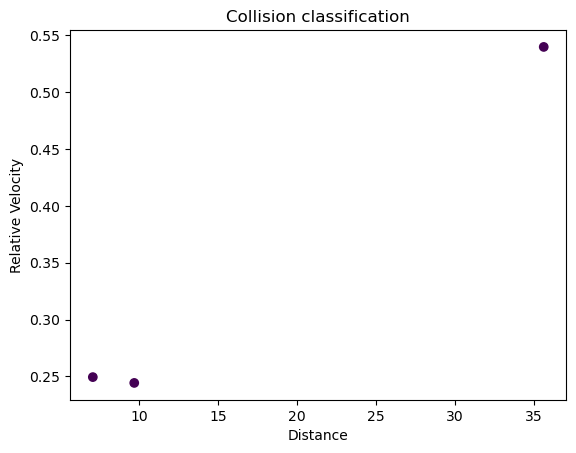

In [9]:
plt.scatter(df_ml["distance"], df_ml["relative_velocity"], c=df_ml["collision"])
plt.xlabel("Distance")
plt.ylabel("Relative Velocity")
plt.title("Collision classification")
plt.show()

## RISK PREDICTION

In [10]:
df_ml["risk"] = predict_risk(model, df_ml)

df_ml.sort_values("risk", ascending=False).head()

NameError: name 'model' is not defined

Key insights:

- Collision risk depends on distance and relative velocity
- Synthetic labeling allows supervised learning
- Simulation enables scalable risk prediction

Limitations:

- Simplified physics
- Synthetic labels
- No real maneuver modeling
